# 04 — Approval Ratings: Analysis

Parallel trends check, DiD regressions, and summary table for Gallup approval ratings.
Loads the cleaned DiD dataset saved by `03_approval_ratings_analysis.ipynb`.

In [ ]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col  # used in section 3 (regression table)
from statsmodels.iolib.table import SimpleTable     # used in section 1 (parallel trends LaTeX export)
import gdown
from scipy import stats  # used in section 1 (linear trend test)

os.makedirs('../output', exist_ok=True)

In [13]:
# Load cleaned DiD dataset from Google Drive

gdown.download(id='17Pe4hqbilLjuSKkx6zEs_z-TQOgthRvF', output='gallup_did_clean.csv', quiet=False)
df = pd.read_csv('gallup_did_clean.csv')


print(f'Loaded {len(df):,} rows | {df["country"].nunique()} countries')
print(f'Treated: {df[df["treated"]==1]["country"].nunique()}  |  Control: {df[df["treated"]==0]["country"].nunique()}')
df.head()


Downloading...
From: https://drive.google.com/uc?id=17Pe4hqbilLjuSKkx6zEs_z-TQOgthRvF
To: /Users/charlesphillips/Documents/GitHub/qss20-final-project/code/gallup_did_clean.csv
100%|████████████████████████████████████████| 245k/245k [00:00<00:00, 4.43MB/s]

Loaded 2,352 rows | 154 countries
Treated: 42  |  Control: 112


,country,year,approve_us,disapprove_us,net_us,approve_china,disapprove_china,net_china,aid_gdp_ratio,treated,avg_aid_gdp,post,did
0,ALBANIA,2025,0.64,0.24,0.40,0.21,0.65,-0.44,0.083221,0,0.111674,1,0
1,ALBANIA,2024,0.64,0.19,0.45,0.16,0.61,-0.45,0.111674,0,0.111674,0,0
2,ALBANIA,2023,0.63,0.16,0.47,0.16,0.55,-0.39,0.133748,0,0.111674,0,0
3,ALBANIA,2022,0.69,0.16,0.53,0.16,0.63,-0.47,0.264855,0,0.111674,0,0
4,ALBANIA,2021,0.82,0.12,0.70,0.31,0.51,-0.20,0.158690,0,0.111674,0,0


## 1. Parallel Trends Assumption

We check that high-aid and low-aid countries trended together in China approval before 2025, then test this statistically with a linear trend in the pre-2025 treated−control gap.

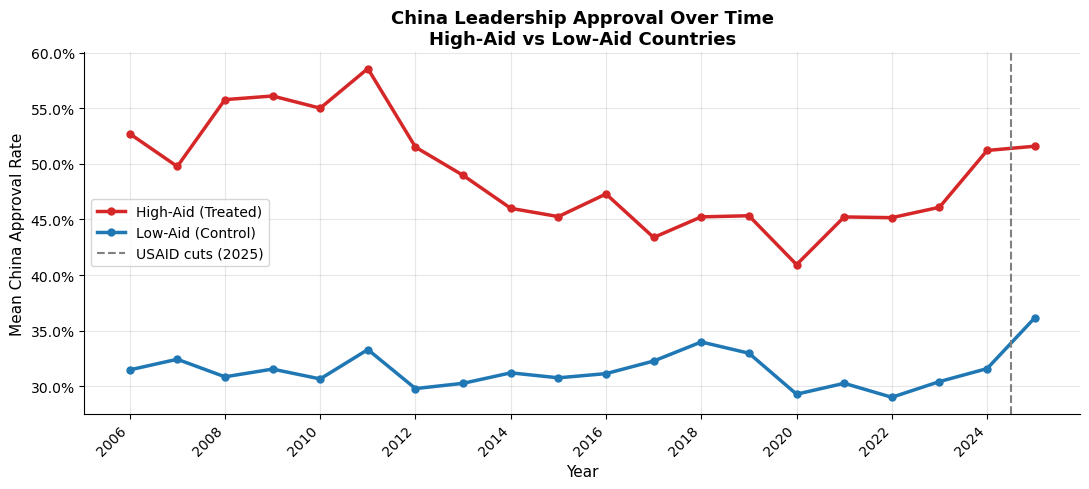

In [14]:
means_pt = (
    df.groupby(['year', 'treated'])['approve_china']
    .mean()
    .reset_index()
)
means_pt['group'] = means_pt['treated'].map({1: 'High-Aid (Treated)', 0: 'Low-Aid (Control)'})
colors_pt = {'High-Aid (Treated)': '#d62728', 'Low-Aid (Control)': '#1f77b4'}

fig, ax = plt.subplots(figsize=(11, 5))

for group, gdf in means_pt.groupby('group'):
    gdf = gdf.sort_values('year')
    ax.plot(gdf['year'], gdf['approve_china'], marker='o', markersize=5,
            label=group, color=colors_pt[group], linewidth=2.5)

ax.axvline(x=2024.5, color='gray', linestyle='--', linewidth=1.5, label='USAID cuts (2025)')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean China Approval Rate', fontsize=11)
ax.set_title('China Leadership Approval Over Time\nHigh-Aid vs Low-Aid Countries',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mtick.MultipleLocator(2))
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../output/parallel_trends_china_approval.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Year-by-year gap + linear trend test (China approval only)
yearly = (
    df.groupby(['year', 'treated'])['approve_china']
    .mean()
    .reset_index()
    .pivot(index='year', columns='treated', values='approve_china')
    .rename(columns={0: 'control', 1: 'treated'})
)
yearly['gap'] = yearly['treated'] - yearly['control']
pre = yearly[yearly.index < 2025]

print(f'{"Year":>6}  {"Treated":>8}  {"Control":>8}  {"Gap":>8}')
print('-' * 38)
for yr, row in yearly.iterrows():
    marker = ' ← treatment' if yr == 2025 else ''
    print(f'{yr:>6}  {row["treated"]:>8.3f}  {row["control"]:>8.3f}  {row["gap"]:>8.3f}{marker}')

pre_years = pre.index.values.astype(float)
pre_gaps  = pre['gap'].values
slope, intercept, r, p_trend, se_slope = stats.linregress(pre_years, pre_gaps)

print(f'\nPre-2025 gap — mean: {pre_gaps.mean():.4f}  std: {pre_gaps.std():.4f}')
print(f'Linear trend test:  slope = {slope:.6f}  |  p = {p_trend:.4f}',
      '  ✓ No trend' if p_trend > 0.05 else '  ✗ Significant trend')

  Year   Treated   Control       Gap
--------------------------------------
  2006     0.527     0.315     0.212
  2007     0.498     0.324     0.173
  2008     0.558     0.309     0.249
  2009     0.561     0.316     0.245
  2010     0.550     0.307     0.243
  2011     0.586     0.333     0.253
  2012     0.515     0.298     0.217
  2013     0.490     0.303     0.187
  2014     0.460     0.312     0.148
  2015     0.453     0.308     0.145
  2016     0.473     0.311     0.161
  2017     0.434     0.323     0.111
  2018     0.452     0.340     0.112
  2019     0.453     0.330     0.124
  2020     0.409     0.293     0.116
  2021     0.452     0.303     0.149
  2022     0.452     0.290     0.161
  2023     0.461     0.304     0.157
  2024     0.512     0.316     0.196
  2025     0.516     0.362     0.154 ← treatment

Pre-2025 gap — mean: 0.1769  std: 0.0469
Linear trend test:  slope = -0.005386  |  p = 0.0040   ✗ Significant trend


In [20]:
from statsmodels.iolib.table import SimpleTable

headers = ['Statistic', 'Value']
data = [
    ['Slope',                   f'{slope:.6f}'],
    ['Std. Error',              f'{se_slope:.6f}'],
    ['R',                       f'{r:.4f}'],
    ['p-value',                 f'{p_trend:.4f}'],
    ['Significant (p < 0.05)',  'No' if p_trend > 0.05 else 'Yes'],
]

tbl = SimpleTable(data, headers, title='Parallel Trends: Linear Trend Test (China Leadership Approval)')

with open('../output/approval_linear_test.tex', 'w') as f:
    f.write(tbl.as_latex_tabular())
print("Saved → ../output/approval_linear_test.tex")

Saved → ../output/approval_linear_test.tex


## 2. DiD Regressions

Simple OLS DiD: `outcome ~ treated + post + did` with HC3 standard errors, matching the specification in `02_analyze.ipynb`.

In [16]:
outcomes = [
    ('approve_us',    'US Leadership Approval'),
    ('approve_china', 'China Leadership Approval'),
    ('net_us',        'US Net Approval (approve − disapprove)'),
    ('net_china',     'China Net Approval (approve − disapprove)'),
]

models = {}

for col, label in outcomes:
    model = smf.ols(f'{col} ~ treated + post + did', data=df).fit(cov_type='HC3')
    models[col] = model
    print(f"\n{'='*55}")
    print(f"Outcome: {label}")
    print(f"{'='*55}")
    print(f"  treated (group diff):  {model.params['treated']:+.4f}  (p={model.pvalues['treated']:.3f})")
    print(f"  post (time trend):     {model.params['post']:+.4f}  (p={model.pvalues['post']:.3f})")
    print(f"  DiD (post×treated):    {model.params['did']:+.4f}  (p={model.pvalues['did']:.3f})  ← key")
    print(f"  N={int(model.nobs)}, R²={model.rsquared:.3f}")


Outcome: US Leadership Approval
  treated (group diff):  +0.1426  (p=0.000)
  post (time trend):     -0.0652  (p=0.001)
  DiD (post×treated):    +0.0049  (p=0.898)  ← key
  N=2352, R²=0.107

Outcome: China Leadership Approval
  treated (group diff):  +0.1767  (p=0.000)
  post (time trend):     +0.0493  (p=0.010)
  DiD (post×treated):    -0.0225  (p=0.573)  ← key
  N=2352, R²=0.164

Outcome: US Net Approval (approve − disapprove)
  treated (group diff):  +0.2603  (p=0.000)
  post (time trend):     -0.2202  (p=0.000)
  DiD (post×treated):    +0.0624  (p=0.378)  ← key
  N=2352, R²=0.111

Outcome: China Net Approval (approve − disapprove)
  treated (group diff):  +0.2991  (p=0.000)
  post (time trend):     -0.0325  (p=0.414)
  DiD (post×treated):    +0.0233  (p=0.744)  ← key
  N=2352, R²=0.139


## 3. Summary Table

In [17]:
rows = []
for col, label in outcomes:
    model = models[col]
    ci = model.conf_int().loc['did']
    rows.append({
        'Outcome':      label,
        'DiD Coef':     round(model.params['did'], 4),
        'Std Err':      round(model.bse['did'], 4),
        'p-value':      round(model.pvalues['did'], 3),
        '95% CI Lower': round(ci[0], 4),
        '95% CI Upper': round(ci[1], 4),
        'N':            int(model.nobs),
        'R²':           round(model.rsquared, 3),
    })

summary = pd.DataFrame(rows)
print("Positive DiD = treated countries moved MORE in that direction than control")
print("Net = approve% − disapprove%\n")
summary

Positive DiD = treated countries moved MORE in that direction than control
Net = approve% − disapprove%



,Outcome,DiD Coef,Std Err,p-value,95% CI Lower,95% CI Upper,N,R²
0,US Leadership Approval,0.0049,0.0380,0.898,-0.0696,0.0793,2352,0.107
1,China Leadership Approval,-0.0225,0.0399,0.573,-0.1008,0.0558,2352,0.164
2,US Net Approval (approve − disapprove),0.0624,0.0708,0.378,-0.0763,0.2011,2352,0.111
3,China Net Approval (approve − disapprove),0.0233,0.0715,0.744,-0.1168,0.1634,2352,0.139


In [18]:
from statsmodels.iolib.summary2 import summary_col

table = summary_col(
    [models['approve_us'], models['approve_china'], models['net_us'], models['net_china']],
    model_names=['US Approval', 'China Approval', 'US Net', 'China Net'],
    stars=True,
    regressor_order=['treated', 'post', 'did'],
    drop_omitted=True,
    info_dict={
        'N':  lambda m: f"{int(m.nobs)}",
        'R²': lambda m: f"{m.rsquared:.3f}",
    }
)

print(table)

with open('../output/approval_did_results.tex', 'w') as f:
    f.write(table.as_latex())

print("Saved → ../output/approval_did_results.tex")


               US Approval China Approval   US Net   China Net
--------------------------------------------------------------
treated        0.1426***   0.1767***      0.2603***  0.2991***
               (0.0096)    (0.0091)       (0.0162)   (0.0143) 
post           -0.0652***  0.0493***      -0.2202*** -0.0325  
               (0.0194)    (0.0191)       (0.0413)   (0.0398) 
did            0.0049      -0.0225        0.0624     0.0233   
               (0.0380)    (0.0399)       (0.0708)   (0.0715) 
R-squared      0.1066      0.1637         0.1115     0.1394   
R-squared Adj. 0.1055      0.1627         0.1103     0.1383   
N              2352        2352           2352       2352     
R²             0.107       0.164          0.111      0.139    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
Saved → ../output/approval_did_results.tex
